# Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)

# Load dataset

In [2]:
df = pd.read_csv("Invistico_Airline.csv")

df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


# Explore the datase

In [3]:
df.info()

df.describe()

df.isnull().sum()

df['satisfaction'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  str    
 1   Customer Type                      129880 non-null  str    
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  str    
 4   Class                              129880 non-null  str    
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             129880 non-null

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

# Handle missing data

In [4]:
df = df.dropna()

# Encode categorical variable

In [5]:
df.select_dtypes(include='object').columns

C:\Users\MOSHOOD\AppData\Local\Temp\ipykernel_3904\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['satisfaction', 'Customer Type', 'Type of Travel', 'Class'], dtype='str')

In [6]:
encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

C:\Users\MOSHOOD\AppData\Local\Temp\ipykernel_3904\1448182830.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


# Define features and target

In [7]:
X = df.drop('satisfaction', axis=1)

y = df['satisfaction']

# Split dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic regression

In [20]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [21]:
y_pred = model.predict(X_test)

# Evaluation

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8281720596185034


In [23]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.8416010219288907


In [24]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.8424380194643745


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11821
           1       0.84      0.84      0.84     14077

    accuracy                           0.83     25898
   macro avg       0.83      0.83      0.83     25898
weighted avg       0.83      0.83      0.83     25898



# Confussion matrix

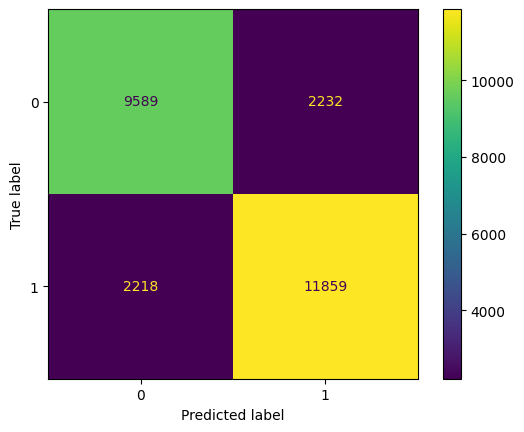

In [26]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

The model correctly classified 9,589 passengers as Dissatisfied (True Negatives) and 11,859 passengers as Satisfied (True Positives). These correct classifications account for the majority of the test observations, demonstrating that the model effectively distinguishes between the two satisfaction classes.
However, the model also made some misclassifications. It incorrectly predicted 2,232 passengers as Satisfied when they were actually  Dissatisfied (False Positives). In addition, 2,218 passengers who were actually Satisfied were incorrectly classified as Dissatisfied (False Negatives).
Overall, the confusion matrix indicates that the model performs well, correctly classifying 21,448 out of 25,976 passengers, which corresponds to an overall accuracy of approximately 82.58%. The relatively balanced number of false positives and false negatives suggests that the model does not exhibit a strong bias toward either class. This balanced performance is consistent with the model's precision, recall, and F1-score, indicating that it provides reliable predictions for identifying both satisfied and neutral/dissatisfied passengers.

# Coefficient Interpretation

In [31]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
10,Inflight entertainment,0.721059
13,On-board service,0.321345
16,Checkin service,0.288851
5,Seat comfort,0.279204
12,Ease of Online booking,0.241530
14,Leg room service,0.236989
18,Online boarding,0.154321
8,Gate location,0.128129
11,Online support,0.114126
15,Baggage handling,0.094087


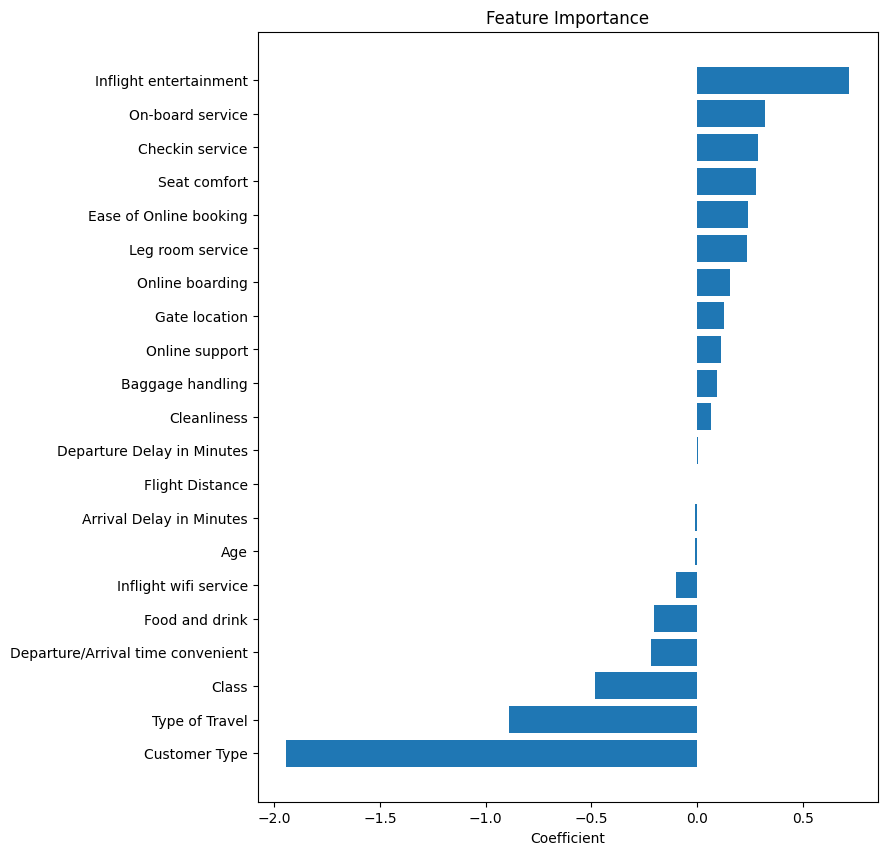

In [30]:
coefficients = coefficients.sort_values(by='Coefficient')
plt.figure(figsize=(8, 10))

plt.barh(coefficients['Feature'], coefficients['Coefficient'])

plt.xlabel("Coefficient")

plt.title("Feature Importance")

plt.show()

**Interpretation**

The table above presents the estimated coefficients from the Logistic Regression model, showing the direction and relative strength of each feature's association with passenger satisfaction. Positive coefficients indicate that higher values of a feature increase the likelihood that a passenger will be classified as **Satisfied**, while negative coefficients indicate a reduced likelihood of satisfaction.
Among all the predictors, **Inflight Entertainment** (0.722) is the strongest positive contributor to passenger satisfaction, suggesting that improvements in entertainment services are strongly associated with higher satisfaction levels. Other important positive factors include **On-board Service**, **Seat Comfort**, **Check-in Service**, **Ease of Online Booking**, and **Leg Room Service**, highlighting the importance of delivering a high-quality onboard and pre-flight experience.
On the other hand, **Customer Type** (-1.946) has the strongest negative coefficient. Based on the label encoding (Loyal Customer = 0, Disloyal Customer = 1), this indicates that **disloyal customers are less likely to be satisfied than loyal customers**. Similarly, **Type of Travel** (-0.891) suggests that **personal travelers are less likely to be satisfied than business travelers**, while the negative coefficient for **Class** (-0.482) indicates that passengers traveling in **Economy or Eco Plus** are generally less likely to report satisfaction than those traveling in **Business Class**.
Additionally, **Arrival Delay in Minutes** (-0.008) demonstrates that longer arrival delays reduce the likelihood of passenger satisfaction, emphasizing the importance of operational efficiency and on-time performance.
Overall, the model indicates that passenger satisfaction is primarily driven by the quality of onboard services, comfort, and customer loyalty. These findings provide valuable insights that can help airline management prioritize investments in service quality, customer retention programs, and operational improvements to enhance the overall passenger experience.

### Overall Business Interpretation
The Logistic Regression model achieved an **accuracy of 82.58%**, demonstrating good predictive performance in classifying passenger satisfaction. The analysis identified **Inflight Entertainment, On-board Service, Seat Comfort, Check-in Service,** and **Ease of Online Booking** as the strongest positive drivers of satisfaction. Conversely, **Disloyal Customer, Personal Travel, Economy Class,** and **Arrival Delay in Minutes** were associated with a lower likelihood of passenger satisfaction. These findings indicate that both service quality and operational efficiency play a critical role in shaping the overall passenger experience.

### Model Limitations
The Logistic Regression model assumes a linear relationship between the predictor variables and the log-odds of the target variable, which may not capture more complex patterns in passenger satisfaction. Label encoding was used for categorical variables, which may introduce an artificial ordering for nominal categories such as travel class. Additionally, the model does not account for potential interactions between features. Future work could explore advanced classification algorithms such as Random Forest, Gradient Boosting, or XGBoost, along with one-hot encoding and hyperparameter tuning, to improve predictive performance.
### Conclusion
This project successfully developed and evaluated a Logistic Regression model for predicting airline passenger satisfaction. The model demonstrated strong performance across multiple evaluation metrics, including **82.58% accuracy**, **84.09% recall**, and balanced precision and F1-scores. The results show that service quality, customer loyalty, and operational performance are the primary factors influencing passenger satisfaction. These insights can support data-driven decisions that enhance customer experience, improve retention, and strengthen the airline's competitive advantage.